<a href="https://colab.research.google.com/github/GUNAPILLCO/neural_profit/blob/main/5_transformer_90_model/5_0_2_hypothesis_alpha_factors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5_0_2_hypothesis_alpha_factors


## Introducción

Esta notebook desarrolla la construcción y validación de alpha factors aplicados al índice MNQ. A partir de hipótesis inspiradas en análisis técnico, se generan variables diseñadas para anticipar retornos futuros. Se evalúa su poder predictivo mediante el Information Coefficient (IC) y se guarda un dataset enriquecido con los factores validados, listo para etapas posteriores de selección y modelado.

0. Configuración del Entorno

    Se prepara el ambiente conectando Google Drive y clonando el repositorio. Se instalan librerías necesarias como pandas, numpy, matplotlib, scipy y ta. Se importan los módulos de soporte del proyecto y se carga el dataset base mnq_intraday_data en formato Parquet. Se muestra un resumen con fechas, número de registros por jornada y consistencia temporal de los datos.

1. Introducción al alpha factor

    Un alpha factor es una señal cuantitativa diseñada para anticipar movimientos futuros del mercado. A diferencia de un indicador técnico tradicional, que es simplemente una fórmula estandarizada, un alpha factor es aquel que demuestra correlación con retornos futuros y, por lo tanto, posee valor predictivo. La sección explica esta diferencia y establece el marco conceptual para formular hipótesis sobre factores de alpha.

2. Hipótesis formuladas

    Se plantean hipótesis específicas de alpha factors a partir de intuiciones de análisis técnico. Cada hipótesis describe una posible relación entre patrones del precio o volumen y los retornos futuros. Se construyen factores derivados de esas hipótesis, como señales de reversión tras movimientos extremos, momentum estandarizado, indicadores de sobrecompra/sobreventa o factores de volatilidad. Estas hipótesis se transforman en columnas del dataset para ser evaluadas empíricamente.

3. Calculo de Information Coefficient (IC)

    Para cada alpha factor generado se calcula el Information Coefficient (correlación de Spearman) frente a los retornos futuros en distintos horizontes. Se agrupan los resultados por día, se obtiene el promedio y la desviación estándar de cada factor y se presentan tablas y gráficos que permiten evaluar su fuerza y estabilidad. El análisis ayuda a identificar qué hipótesis producen señales con verdadero valor predictivo y cuáles resultan débiles o inconsistentes.

4. Guardado de dataset de alpha factors

    Finalmente, se construye un dataset enriquecido que incluye las variables OHLCV originales, los retornos futuros definidos como targets y los alpha factors validados. Este dataset se guarda en formato Parquet dentro de la carpeta 2_feature_engineering para ser utilizado en etapas posteriores de correlación, selección de variables y modelado predictivo.

## 0. Configuración del Entorno




### 0.1. Clonado de repositorio / Acceso a Drive



In [1]:
#Clonamos el repo
#LINK DE REPOSITORIO: https://github.com/GUNAPILLCO/neural_profit
#!git clone https://github.com/GUNAPILLCO/neural_profit.git

In [2]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/neural_profit"

Mounted at /content/drive


### 0.2. Instalación de librerías

In [3]:
#!{sys.executable} -m pip install -q ta
#print("Librería instalada: technical-analysis")

### 0.3. Importación de librerías


In [4]:
import sys
import re
from functools import reduce

#Instalación de librería pandas_market_calendars
#!{sys.executable} -m pip install -q pandas_market_calendars
#print("Librería instalada: pandas_market_calendars")

# Utilidades generales
from datetime import datetime, timedelta
import os
import glob
import requests
import warnings
warnings.filterwarnings('ignore')

# Manejo y procesamiento de datos
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
# Calendario de mercados
#import pandas_market_calendars as mcal


#from ta.momentum import StochasticOscillator, ROCIndicator
#from ta.volatility import BollingerBands, AverageTrueRange

from scipy.stats import spearmanr

### 0.4. Carga de dataset MNQ



In [5]:
def load_data():
    """
    Función para cargar un archivo Parquet desde el repositorio clonado
    """
    # Definir la URL del archivo Parquet en GitHub
    #df_path = '/content/neural_profit/2_obtencion_preparacion_exploracion_datos/mnq_intraday_data.parquet'
    data_path = f'{drive_path}/5_transformer_90_model/mnq_intraday_data.parquet'
    # Leer el archivo Parquet y cargarlo en un DataFrame
    df = pd.read_parquet(data_path)

    # Asegurar que el índice esté en formato datetime
    df.index = pd.to_datetime(df.index)

    # Crear una nueva columna 'date' con la fecha extraída del índice
    df['date'] = df.index.date

    # Reordenar columnas: 'date', 'time_str', y luego el resto
    cols = ['date'] + [col for col in df.columns if col not in ['date']]

    df = df[cols]

    return df

In [6]:
mnq_intraday = load_data()

### 0.5. Info de dataset MNQ

In [7]:
def info_dataset(df):
  print("Información del dataset:\n")

  # Contar valores únicos en la columna 'date'
  num_dias = df['date'].nunique()
  print(f"\tCantidad de días: {num_dias}")

  # Filtrar valores válidos
  validos_por_dia = df.dropna(subset=['close']).groupby('date').size()

  # Calcular el promedio
  promedio_por_fecha = validos_por_dia.mean()
  print(f"\tRegistros por día: {int(promedio_por_fecha)}")

  primer_hora = df.index[0].strftime('%H:%M')
  ultima_hora = df.index[-1].strftime('%H:%M')
  zona_horaria = df.index[0].tzinfo


  print(f"\tHora diaria de inicio {primer_hora}")
  print(f"\tHora diaria de final {ultima_hora}")
  print(f"\tZona horaria: {zona_horaria}")

In [8]:
info_dataset(mnq_intraday)

Información del dataset:

	Cantidad de días: 1303
	Registros por día: 601
	Hora diaria de inicio 06:00
	Hora diaria de final 16:00
	Zona horaria: America/New_York


## 1. Introducción al alpha factor

Un alpha factor es una señal cuantitativa **diseñada** para anticipar movimientos del mercado. Es decir, es una variable que resume información de precios, volúmenes u otras fuentes, y que tiene poder predictivo sobre el rendimiento futuro de un activo.

Cómo diferenciarlo de un indicador técnico:

- Un indicador técnico es una fórmula estándar (ejemplo: RSI, MACD, medias móviles).

- Un alpha factor, en cambio, es un indicador que ha demostrado tener correlación con retornos futuros. No todos los indicadores técnicos lo son: solo los que muestran capacidad de predecir.

Un alpha factor es como una hipótesis cuantitativa: propone que una cierta transformación de los datos (por ejemplo, un RSI bajo o un volumen inusualmente alto) podría anticipar un movimiento futuro del precio.

Entonces, antes de entrenar un modelo LSTM, XGBoost o cualquier otro, el alpha factor te ayuda a descubrir cuáles features tienen “potencial predictivo”

**¿Qué hace realmente?**

- Evalúa si una variable (feature) tiene relación estadística con el retorno futuro.
- Te filtra las señales útiles del ruido.
- Acelera la selección de features sin tener que probar todo con modelos complejos primero.

Por ejemplo:

- Calculás el momentum 10 y ves que cuando es alto, el retorno a 5 minutos tiende a ser positivo → ese factor tiene alpha.
- Calculás el RSI 14 y no ves ninguna relación → ese factor no tiene alpha (en ese timeframe).


El Information Coefficient (IC) mide la correlación entre el alpha factor y el retorno futuro:

- IC > 0: el factor predice correctamente la dirección del retorno.
- IC ≈ 0: el factor no tiene poder predictivo.
- IC < 0: el factor tiene un poder inverso (indica lo contrario al retorno real).

Recordemos que nuestro target es el retorno de la variables 'close' y lo evaluaremos en tres ventanas de tiempo: 5, 15, 30, 60 y 90 minutos.

In [9]:
def add_targets (df):
  #Del calculo de indicadores técnicos pudimos observar que en ventanas cortas de 5 y 15min no suman valor predictivo-
  df['target_return_90'] = df.groupby('date')['close'].transform(lambda x: np.log(x.shift(-90)) - np.log(x))
  return df

In [10]:
mnq_intraday = add_targets(mnq_intraday)

## 2. Hipotesis formuladas

### 2.1. Hipotesis 1: Continuación del Momentum Intradía

**"Si el precio ha subido de forma constante en los últimos N minutos, es probable que continúe subiendo en los próximos minutos."**
<br><br>
**Justificación técnica:** <br>
Basada en la idea de momentum. Los traders tienden a subirse a la ola cuando ven un movimiento fuerte, generando continuación.
<br><br>
**Alpha Factor sugerido:** <br>Se define un factor de momentum como la diferencia entre los logaritmos del precio de cierre actual y el precio de cierre hace `N` minutos:

$$
\text{momentum}_t^{(N)} = \log(\text{close}_t) - \log(\text{close}_{t-N})
$$

Este valor puede interpretarse como el retorno logarítmico acumulado en los últimos `N` minutos. Valores positivos indican tendencia alcista reciente, mientras que valores negativos reflejan presión bajista.

**Parámetros recomendados para N:**  
- Corto plazo: `N = 5`
- Medio plazo: `N = 15`
- Largo plazo intradía: `N = 30`

**Aplicación:**

Este factor puede utilizarse como variable predictora en modelos supervisados, o directamente para generar señales de trading (ej: entrar en largo cuando Momentum > 0).

In [11]:
def calcular_momentum_z(
    df,
    target='close',
    #ventanas=(10, 15, 20, 30, 45, 60,90),
    ventanas=(90),
    hipotesis='continuacion'
    ):
    """
    Calcula, por día, el momentum logarítmico a N minutos y su estandarización (z-score).
    Puede calcularse bajo la hipótesis de continuación (z-score normal) o reversión (z-score con signo invertido).

    Parámetros
    ----------
    df : pd.DataFrame
        Debe contener columnas ['date', target].
    target : str
        Columna de precio a usar (ej. 'close').
    ventanas : iterable[int]
        Ventanas N (en minutos) para calcular el z-score del momentum.
    hipotesis : str, default 'continuacion'
        Si es 'continuacion', devuelve momentum_z_N.
        Si es 'reversion', devuelve rev_momentum_z_N (signo invertido).

    Retorna
    -------
    df_out : pd.DataFrame
        DataFrame original con nuevas columnas agregadas.
    cols_creadas : list[str]
        Lista de columnas creadas.
    """

    if hipotesis not in ['continuacion', 'reversion']:
        raise ValueError("hipotesis debe ser 'continuacion' o 'reversion'")

    # nombres de columnas según hipótesis
    if hipotesis == 'continuacion':
        cols = [f"mom_z_{N}" for N in ventanas]
    else:
        cols = [f"rev_mom_z_{N}" for N in ventanas]

    def aplicar_por_dia(grupo: pd.DataFrame) -> pd.DataFrame:
        g = grupo.copy()

        for N in ventanas:
            # momentum logarítmico crudo
            raw = np.log(g[target]) - np.log(g[target].shift(N))

            mu = raw.mean(skipna=True)
            sd = raw.std(skipna=True)

            if pd.isna(sd) or sd == 0:
                z = np.nan
            else:
                z = (raw - mu) / sd
                if hipotesis == 'reversion':
                    z = -z

            col = f"mom_z_{N}" if hipotesis == 'continuacion' else f"rev_mom_z_{N}"
            g[col] = z

        return g

    df_out = df.groupby('date', group_keys=False).apply(aplicar_por_dia)
    return df_out, cols

#### 2.1.1. Replanteo de Hipotesis 1:

Hipótesis alternativa: **Si el precio subió mucho en los últimos N minutos, es probable que revierta (baje).**

- Si el momentum ha sido muy alto (positivo), se espera una reversión bajista → señal negativa.
- Si ha sido muy bajo (negativo), se espera una reversión alcista → señal positiva.



### 2.2. Hipotesis 2: Reversión a la Media (Mean Reversion)

**"Si el precio se aleja demasiado de su media móvil de corto plazo, tenderá a volver a ella."**
<br><br>
**Justificación técnica:**<br>
Alta frecuencia tiende a mostrar sobre-reacciones temporales. Este es un principio clásico del análisis técnico. En escalas de tiempo cortas, los precios tienden a oscilar alrededor de su media. Alejamientos extremos suelen generar correcciones rápidas, especialmente en activos líquidos como el MNQ.
<br><br>
**Alpha Factor sugerido:**
$$
\text{mean_reversion_factor}(t) = \frac{close(t) - \text{SMA}_N(t)}{\sigma_N(t)}
$$

Donde:
- $ \text{SMA}_N(t) $ es la media móvil simple de los últimos N minutos.
- ${\sigma_N(t)}$ es la desviación estándar en la misma ventana.


**El z-score te dice cuán lejos está un valor respecto a su promedio, medido en unidades de desviación estándar.**
<br>
Es una forma de medir si algo está “muy arriba” o “muy abajo” de lo normal.

In [13]:
#Hipotesis 2
def calcular_reversal_score(
    df,
    target='close',
    #ventanas=(10, 15, 20, 30, 45, 60,90),
    ventanas=(90),
    eps=1e-8
    ):

    """
    Hipótesis 2: factor de reversión basado en z-score intradía.
    - Para cada día: z = (price - SMA_N) / STD_N con ventana N.
    - Estandarizamos ese z intradía: (z - mean(z_día)) / std(z_día).
    - Se calcula por bloques diarios (no hay continuidad entre días).

    Parámetros
    ----------
    df : DataFrame con columnas ['date', target]
    target : str, columna de precio (por defecto 'close')
    ventanas : iterable de int, tamaños de ventana en minutos
    eps : float, para evitar divisiones por cero

    Retorna
    -------
    df : DataFrame con nuevas columnas 'reversal_score_{N}'
    rev_columns : list[str], nombres de columnas añadidas
    """
    rev_columns = [f'rev_score_{N}' for N in ventanas]

    def _aplicar_por_dia(grupo: pd.DataFrame) -> pd.DataFrame:
        grupo = grupo.copy()
        s = grupo[target].astype(float)

        for N in ventanas:
            # Medias y desvíos rodantes intradía (min_periods=1 para comenzar cuanto antes)
            sma = s.rolling(window=N, min_periods=1).mean()
            std = s.rolling(window=N, min_periods=1).std(ddof=0)

            # z-score intradía para ventana N
            z = (s - sma) / (std.replace(0.0, np.nan) + eps)

            # Estandarización dentro del mismo día (sin mezclar con otros días)
            z_mean = z.mean(skipna=True)
            z_std = z.std(ddof=0, skipna=True)

            col = f'rev_score_{N}'
            grupo[col] = (z - z_mean) / (z_std + eps)

        return grupo

    df = df.groupby('date', group_keys=False).apply(_aplicar_por_dia)
    return df, rev_columns

### 2.3. Hipotesis 3: Volumen como confirmación de dirección

**"Un movimiento alcista con aumento de volumen tiene más chances de continuar."**
<br><br>
**Justificación técnica:**<br>
Esta hipótesis está basada en un principio clásico del análisis técnico: el volumen confirma la tendencia. Si hay momentum y ese movimiento está respaldado por un volumen inusualmente alto, la probabilidad de que continúe el movimiento es mayor.
<br><br>
**Alpha Factor sugerido:**

$$
\text{Factor}_t = \text{Momentum}_t \times \left( \frac{\text{volume}_t}{\text{VolumenPromedio}_N} \right)
$$

Donde:  
- $\text{Momentum}_t$ es el retorno logarítmico del precio en los últimos $N$ minutos.  
- $\text{VolumenPromedio}_N$ es la media móvil del volumen en una ventana de $N$ minutos.

Usamos N = 5, 15 y 30 como en las hipotesis anteriores.


In [14]:
def calcular_momentum_vol_z(
    df,
    target_price='close',
    target_vol='volume',
    ventanas=(90),
    hipotesis='continuacion',
    eps=1e-8
):
    """
    Hipótesis 3: factor = momentum_N * (volumen / media_rodante_volumen_N),
    estandarizado intradía (z-score por día).

    Parámetros
    ----------
    df : pd.DataFrame con columnas ['date', target_price, target_vol]
    target_price : str, nombre de columna de precio (default 'close')
    target_vol : str, nombre de columna de volumen (default 'volume')
    ventanas : iterable de int, tamaños de ventana (en minutos)
    hipotesis : str, 'continuacion' (default) o 'reversion'
        - 'continuacion' → columnas mom_vol_z_{N}
        - 'reversion' → columnas rev_mom_vol_z_{N}
    eps : float, para evitar divisiones por cero

    Retorna
    -------
    df : DataFrame con nuevas columnas
    z_columns : list[str], nombres de columnas añadidas
    """

    if hipotesis.lower() == 'continuacion':
        z_columns = [f'mom_vol_z_{N}' for N in ventanas]
    else:
        z_columns = [f'rev_mom_vol_z_{N}' for N in ventanas]

    def _aplicar_por_dia(grupo: pd.DataFrame) -> pd.DataFrame:
        g = grupo.copy()
        p = g[target_price].astype(float)
        v = g[target_vol].astype(float)

        for N in ventanas:
            # Momentum log en ventana N
            mom = np.log(p) - np.log(p.shift(N))

            # Media móvil de volumen intradía
            vavg = v.rolling(window=N, min_periods=1).mean()

            # Ratio de volumen
            vr = v / (vavg.replace(0.0, np.nan) + eps)

            # Factor crudo
            factor = mom * vr

            # Ajuste según hipótesis
            if hipotesis.lower() == 'reversion':
                factor = -factor
                col = f'rev_mom_vol_z_{N}'
            else:
                col = f'mom_vol_z_{N}'

            # Z-score intradía
            mu = factor.mean(skipna=True)
            sd = factor.std(ddof=0, skipna=True)
            g[col] = (factor - mu) / (sd + eps)

        return g

    df = df.groupby('date', group_keys=False).apply(_aplicar_por_dia)
    return df, z_columns

#### 2.3.1. Replanteo de Hipotesis 3:

Hipótesis alternativa: **Cuando hay un gran movimiento de precio con alto volumen, la dirección tiende a revertirse.**

Esto convierte el alpha factor en un indicador de reversión en lugar de continuación.

### 2.4. Hipotesis 4: Exhaustión del rango intradía

**"Si en la primera hora se alcanza un rango de precios muy amplio, el mercado tenderá a consolidar o revertir."**

Justificación técnica: En muchos activos, un rango amplio en la apertura (08:00 a 09:30 US/Eastern) refleja exceso de volatilidad temprana, frecuentemente impulsada por noticias o desequilibrios de oferta/demanda. Este impulso inicial puede agotarse, dando paso a consolidaciones o retrocesos.

Alpha Factor sugerido:
$$
\text{OpeningRange}_{day} = \text{max}(\text{high}_{08:00-09:30}) - \text{min}(\text{low}_{08:00-09:30})
$$

Y luego creamos un factor que mida cuán lejos está el precio actual respecto a ese rango:

$$
\text{Factor}_{t} =  \frac{\text{close}_t - \text{midpoint}_{opening range}}{\text{opening range width}}
$$

Donde:  
- $\text{midpoint}_t = (\text{high}_{open} + \text{low}_{open})/2  $

- Se aplica este factor al resto del día (después de las 09:30)

In [15]:
#Hipotesis 4
def calcular_intraday_range_exhaustion(
    df: pd.DataFrame,
    target_price: str = 'close',
    target_high: str = 'high',
    target_low: str = 'low',
    mins_windows=(90),
    hipotesis: str = 'continuacion',
    open_time: str = "08:00:00",
    require_full_window: bool = False,
    eps: float = 1e-8
):
    """
    Hipótesis 4 (versión por primeros N minutos desde la apertura):
      Para cada día y cada N en mins_windows:
        - t_open = date + open_time
        - Ventana de apertura: [t_open, t_open + N minutos)
        - opening_high/low en esa ventana
        - opening_midpoint = (high + low)/2
        - opening_range = high - low
        - opening_factor_raw = (price - midpoint) / opening_range
          aplicado SOLO para t >= (t_open + N minutos)
        - Estandarización intradía por día y por N: z = (raw - mean_día) / std_día

    Notas:
      - Si el dataset no tiene barras antes de 08:30, se usan las barras disponibles.
      - Si require_full_window=True y no hay N barras en la ventana, se deja NaN.

    Devuelve:
      df: con columnas opening_z_{N} o rev_opening_z_{N}
      z_cols: lista de nombres creados
    """

    # Nombres de salida según hipótesis
    if hipotesis.lower() == 'continuacion':
        z_cols = [f'ire_{N}' for N in mins_windows]
    else:
        z_cols = [f'rev_ire_{N}' for N in mins_windows]

    def _por_dia(g: pd.DataFrame) -> pd.DataFrame:
        g = g.copy()
        day = g.index.normalize()[0]
        t_open = day + pd.to_timedelta(open_time)

        price = g[target_price].astype(float)
        hi = g[target_high].astype(float)
        lo = g[target_low].astype(float)

        for N in mins_windows:
            t_end = t_open + pd.Timedelta(minutes=N)
            win_mask = (g.index >= t_open) & (g.index < t_end)

            # Comprobar cantidad de barras en la ventana de apertura
            if require_full_window:
                has_enough = win_mask.sum() >= N  # 1-min bars
            else:
                has_enough = win_mask.any()

            if not has_enough:
                z_series = pd.Series(np.nan, index=g.index)
            else:
                hi_win = hi.where(win_mask).max()
                lo_win = lo.where(win_mask).min()

                rng = hi_win - lo_win
                mid = (hi_win + lo_win) / 2 if pd.notna(hi_win) and pd.notna(lo_win) else np.nan

                denom = np.nan if (pd.isna(rng) or rng == 0) else rng
                raw = (price - mid) / (denom if denom not in (None, 0) else np.nan)

                # Solo después del fin de la ventana de apertura
                raw = raw.where(g.index >= t_end)

                mu = raw.mean(skipna=True)
                sd = raw.std(ddof=0, skipna=True)
                z_series = (raw - mu) / (sd + eps)

                if hipotesis.lower() == 'reversion':
                    z_series = -z_series

            col = (f'rev_ire_{N}' if hipotesis.lower() == 'reversion'
                   else f'ire_{N}')
            g[col] = z_series

        return g

    out = df.groupby('date', group_keys=False).apply(_por_dia)
    return out, z_cols

## 3. Calculo de Information Coefficient (IC)

Seguimos los mismos criterios que usamos para los indicadores técnicos, tanto para la Media de IC (`ic_mean`) como para la Desviación Estándar de IC (`ic_std`)

### 3.0. Funciones

#### Función para calcular ic_mean e ic_std

In [16]:
def calcular_IC(df: pd.DataFrame, target: str, factors: list[str]):
    grouped = df.groupby('date')

    #print(f"IC promedio por factor (diario) sobre el {target}:\n")

    resultados = []

    for factor in factors:
        daily_ics = []

        for date, group in grouped:
            df_valid = group[[factor, target]].dropna()
            if len(df_valid) >= 20:
                ic = spearmanr(df_valid[factor], df_valid[target]).correlation
                if np.isfinite(ic):
                    daily_ics.append(ic)

        # Buscar todos los dígitos consecutivos en el string
        ventana_target = re.findall(r'\d+', target)[0]

        if daily_ics:
            mean_ic = np.mean(daily_ics)
            std_ic = np.std(daily_ics)
            dias_validos = len(daily_ics)
            #Quita el # si quieres ver los resultados paso a paso
            #print(f"{factor:15}: IC medio = {mean_ic:.4f} | std = {std_ic:.4f} | días válidos = {dias_validos}")
            resultados.append({
                'indicador': factor,
                f'ic_mean_{ventana_target}min': mean_ic,
                f'ic_std_{ventana_target}min': std_ic,

            })
        else:
            print(f"{factor:15}: sin días válidos para cálculo")

    return pd.DataFrame(resultados)

#### Función para plotear ic_mean e ic_std

In [20]:
def plot_ic_mean_std(df, sentido = 'continuación', titulo_mean="ic_mean por target", titulo_std="ic_std por target"):
    # Detectar todas las columnas ic_mean_*min e ic_std_*min
    mean_cols = [c for c in df.columns if re.match(r'^ic_mean_\d+min$', c)]
    std_cols = [c for c in df.columns if re.match(r'^ic_std_\d+min$', c)]

    # Extraer ventanas (ej: 5,15,30,60,90)
    ventanas = sorted([int(re.findall(r'\d+', c)[0]) for c in mean_cols])

    x = range(len(df["indicador"]))
    bar_width = 0.08

    # Crear figura con 2 subplots (izquierda mean, derecha std)
    fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=False)

    # --- Subplot izquierda: IC mean ---
    for i, v in enumerate(ventanas):
        mcol = f"ic_mean_{v}min"
        axes[0].bar(
            [p + i*bar_width for p in x],
            df[mcol],
            width=bar_width,
            label=f"{v} min"
        )
    axes[0].set_xticks([p + bar_width*(len(ventanas)/2) for p in x])
    axes[0].set_xticklabels(df["indicador"])
    axes[0].set_ylabel("ic_mean")
    axes[0].set_title(titulo_mean)
    axes[0].legend(title="target")

    # Helper para anotar líneas sin invadir las barras
    def _annot_line(ax, y, text, color="tab:red"):
        ax.axhline(y=y, linestyle="--", linewidth=0.7, alpha=0.6, color=color)
        ax.annotate(
            text,
            xy=(0.01, y),                     # 1% desde el borde izq del eje X
            xycoords=("axes fraction", "data"),
            textcoords="offset points",
            xytext=(0, 2 if y >= 0 else -2),  # pequeño desplazamiento
            ha="left",
            va="bottom" if y >= 0 else "top",
            fontsize=7,
            color=color,
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", boxstyle="round,pad=0.15"),
            zorder=5
        )

    # Línea base
    _annot_line(axes[0], 0.0, "0 (sin señal)", color="black")

    # Líneas según sentido (positivas o negativas)
    sign = 1 if sentido == "continuación" else -1
    _annot_line(axes[0], sign*0.05, f"{'+' if sign>0 else '-'}0.05 - Señal débil)", color="tab:red")
    _annot_line(axes[0], sign*0.10, f"{'+' if sign>0 else '-'}0.10 - Señal fuerte)", color="tab:green")


    # --- Subplot derecha: IC std ---
    for i, v in enumerate(ventanas):
        scol = f"ic_std_{v}min"
        axes[1].bar(
            [p + i*bar_width for p in x],
            df[scol],
            width=bar_width,
            label=f"{v} min"
        )
    axes[1].set_xticks([p + bar_width*(len(ventanas)/2) for p in x])
    axes[1].set_xticklabels(df["indicador"])
    axes[1].set_ylabel("ic_std")
    axes[1].set_title(titulo_std)
    axes[1].legend(title="target")


    # Límites estándar para ic_std (siempre positivos)
    _annot_line(axes[1], 0.10, "y<0.10 - Aceptable", color="tab:green")
    _annot_line(axes[1], 0.20, "0.10<y<0.20 - En Observación", color="tab:red")

    plt.tight_layout()
    plt.show()

### 3.1. Hipotesis 1: Continuación del Momentum Intradía

In [24]:
mnq_hip_1, momentum_cols = calcular_momentum_z(mnq_intraday, target='close', ventanas=[90]) #, contrarian=False)

In [25]:
#IC_hip1_30 = calcular_IC(mnq_hip_1, target='target_return_30', factors=momentum_cols)
#IC_hip1_60 = calcular_IC(mnq_hip_1, target='target_return_60', factors=momentum_cols)
IC_hip1_90 = calcular_IC(mnq_hip_1, target='target_return_90', factors=momentum_cols)

In [26]:
#IC_hip1 = [IC_hip1_5, IC_hip1_15, IC_hip1_30, IC_hip1_60, IC_hip1_90]
#IC_hip1 = [IC_hip1_30, IC_hip1_60, IC_hip1_90]
IC_hip1 = [IC_hip1_90]
IC_hip1 = reduce(lambda left, right: pd.merge(left, right, on="indicador", how="inner"), IC_hip1)
IC_hip1

,indicador,ic_mean_90min,ic_std_90min
0,mom_z_90,-0.253702,0.258561


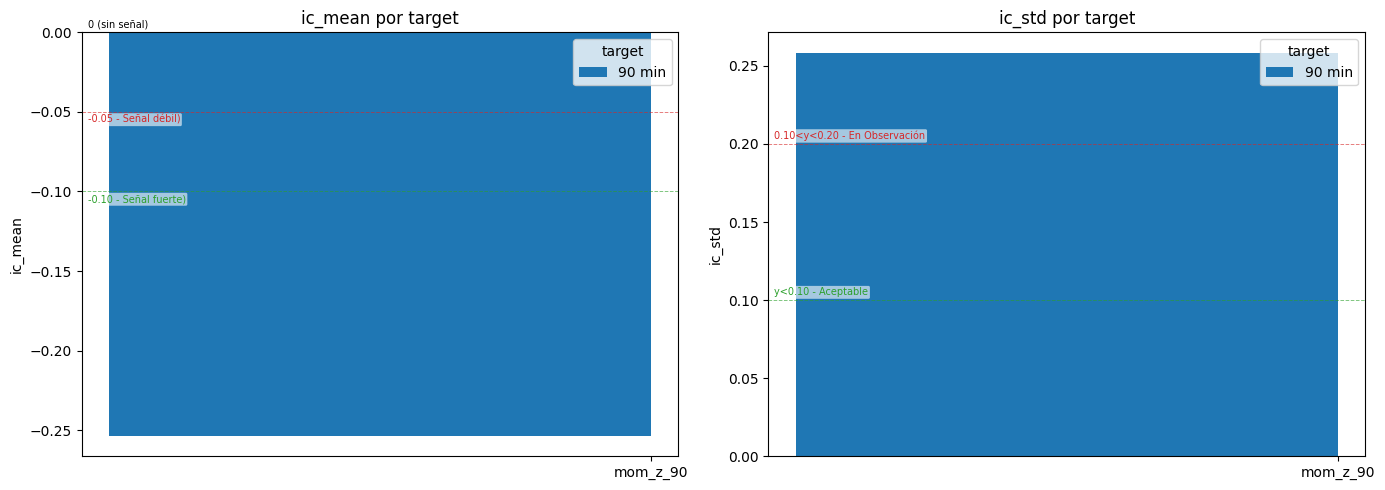

In [27]:
plot_ic_mean_std(IC_hip1, sentido = 'reversión')

#### 3.1.1. Análisis

1. Signo del IC (Information Coefficient)  

    - Todos los valores de `ic_mean` son negativos y se vuelven más negativos a medida que aumenta la ventana del target (30 → 60 → 90 min).  
    - Esto implica que cuando el `mom_z_N` es alto (positivo), la probabilidad es mayor de que el retorno futuro (30–90 min) sea bajo o negativo, es decir, una señal de reversión y no de continuación.

2. Magnitud del IC  

   - Para ventanas cortas (`mom_z_10` o `mom_z_15`), el IC es pequeño (cercano a -0.05 / -0.09), lo que indica una señal débil.  
   - Conforme aumenta el horizonte (`mom_z_60`, `mom_z_90`), la señal se hace más fuerte (-0.14 → -0.30), mostrando que el efecto reversivo se amplifica en horizontes largos.

3. Volatilidad de la señal (`ic_std`)  

   - El `ic_std` es alto en comparación al `ic_mean`, lo que significa que la señal no es estable día a día.  
   - Existe mucha dispersión: algunos días puede dar buena predicción, otros días no tanto (incluso con signo contrario).  
   - Ejemplo: para `mom_z_90`, el promedio es -0.30, pero con una dispersión de 0.32. La señal existe, pero es ruidosa.


#### 3.1.2. Conclusiones

- La hipótesis de continuación de tendencia (momentum) no se valida en el dataset.  
- Los resultados apoyan una hipótesis de reversión a la media:  
  > Cuando el momentum de corto plazo está muy alto (positivo), los retornos futuros tienden a revertir y ser negativos, y viceversa.  
- La fuerza de esta reversión crece con el horizonte temporal del target (más clara a 60–90 minutos).  
- El problema es que la señal es volátil (alto `ic_std`), por lo que puede requerir filtrado, combinación con otros factores o restricciones (por ejemplo, solo usar señales extremas) para ser utilizable en trading.

#### 3.1.3. Replanteo de Hipotesis 1 como señal de reversión

In [29]:
mnq_hip_1_rev, momentum_rev_cols = calcular_momentum_z(mnq_intraday, target='close', ventanas=[90], hipotesis='reversion')

In [30]:
#Solo lo calculamos para las ventanas mayores de 30min
#IC_hip1_rev_30 = calcular_IC(mnq_hip_1_rev, target='target_return_30', factors = momentum_rev_cols)
#IC_hip1_rev_60 = calcular_IC(mnq_hip_1_rev, target='target_return_60', factors = momentum_rev_cols)
IC_hip1_rev_90 = calcular_IC(mnq_hip_1_rev, target='target_return_90', factors = momentum_rev_cols)

In [31]:
#IC_hip1_rev = [IC_hip1_rev_30, IC_hip1_rev_60, IC_hip1_rev_90]
IC_hip1_rev = [IC_hip1_rev_90]
IC_hip1_rev = reduce(lambda left, right: pd.merge(left, right, on="indicador", how="inner"), IC_hip1_rev)
IC_hip1_rev

,indicador,ic_mean_90min,ic_std_90min
0,rev_mom_z_90,0.253702,0.258561


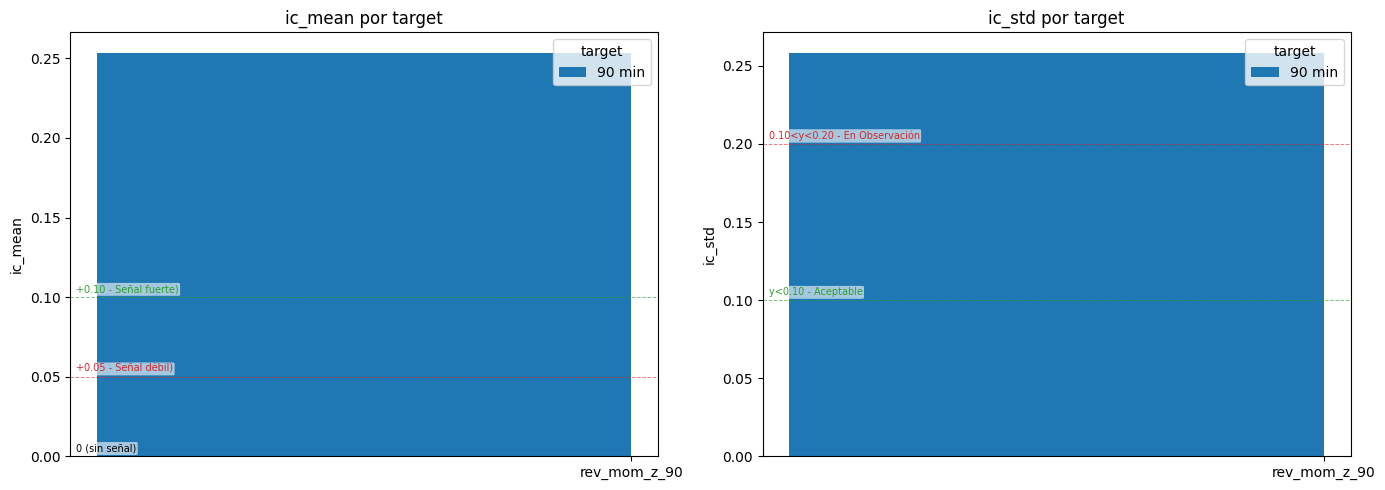

In [32]:
plot_ic_mean_std(IC_hip1_rev, sentido = 'continuación')

#### 3.1.4. Análisis de replanteo

1. Signo y consistencia del IC

    - Los valores de `ic_mean` son positivos en todos los horizontes (30, 60, 90 min).  
    - Esto valida que el `momentum_z` invertido (`rev_mom_z`) contiene información predictiva con signo correcto: a mayor exceso de momentum, mayor probabilidad de reversión futura.

2. Magnitud del IC

    - Para 30 min: `rev_mom_z_30` ≈ 0.09 → señal débil pero presente.  
    - Para 60 min: `rev_mom_z_60` ≈ 0.20 → señal más clara.  
    - Para 90 min: `rev_mom_z_90` ≈ 0.30 → señal fuerte.  
    - Se observa un patrón claro: la señal se fortalece con el horizonte del target.

3. Volatilidad de la señal (`ic_std`)

    - Los valores de `ic_std` se ubican entre 0.19 y 0.32.  
    - Según la escala planteada:  
      - Entre 0.10 y 0.20 → aceptable o en observación.  
      - Por encima de 0.20 → bastante volátil.  
    - Esto indica que, aunque la señal es clara en promedio, su rendimiento es heterogéneo entre días. Habrá jornadas muy predictivas y otras sin señal o incluso con ruido.

4. Relación señal-ruido

    - La relación entre `ic_mean` y `ic_std` muestra:  
      - Para 30 min: 0.09 / 0.19 ≈ 0.47 (débil).  
      - Para 60 min: 0.20 / 0.26 ≈ 0.76 (moderada).  
      - Para 90 min: 0.30 / 0.32 ≈ 0.94 (muy buena relación).  
    - A mayor horizonte, no solo aumenta el IC, sino que la señal se mantiene relativamente más robusta frente al ruido.

#### 3.1.5. Conclusiones del replanteo de Hipotesis 1

  - La hipótesis 1 (como señal de reversión) se valida con claridad.  
  - Los factores `rev_mom_z_45`, `rev_mom_z_60` y `rev_mom_z_90` resultan los más informativos.  
  - El horizonte de 90 minutos es el más prometedor en cuanto a fuerza de la señal.  
  - Debido a la dispersión elevada (`ic_std`), es recomendable:  
    - Usar estos factores en conjunto con otros (RSI, Bollinger, etc.).  
    - Considerar filtros, por ejemplo tomar solo señales extremas (|z| > 1).  
    - Aplicar regularización en los modelos para evitar que días ruidosos tengan demasiado peso.

#### 3.1.6 Conclusión final


La hipótesis de reversión se valida y muestra un patrón consistente: cuanto mayor es el horizonte de retorno, más fuerte es la señal. Para el modelo predictivo conviene conservar como features los factores `rev_mom_z_45`, `rev_mom_z_60` y `rev_mom_z_90`, ya que aportan la mayor información. De forma complementaria, `rev_mom_z_30` puede incluirse para capturar efectos de corto plazo, aunque su valor añadido es menor. En conjunto, estos factores de reversión enriquecen la capacidad predictiva del modelo al aportar una señal clara y robusta en horizontes medios y largos.

### 3.2. Hipotesis 2: Reversión a la media (Mean Reversion)

In [34]:
mnq_hip_2, reversal_score_cols = calcular_reversal_score(mnq_intraday, target='close', ventanas=[90]) #, contrarian=False)

In [35]:
#IC_hip2_30 = calcular_IC(mnq_hip_2, target='target_return_30', factors=reversal_score_cols)
#IC_hip2_60 = calcular_IC(mnq_hip_2, target='target_return_60', factors=reversal_score_cols)
IC_hip2_90 = calcular_IC(mnq_hip_2, target='target_return_90', factors=reversal_score_cols)

In [36]:
#IC_hip2 = [IC_hip2_30, IC_hip2_60, IC_hip2_90]
IC_hip2 = [IC_hip2_90]
IC_hip2 = reduce(lambda left, right: pd.merge(left, right, on="indicador", how="inner"), IC_hip2)
IC_hip2

,indicador,ic_mean_90min,ic_std_90min
0,rev_score_90,-0.161521,0.241383


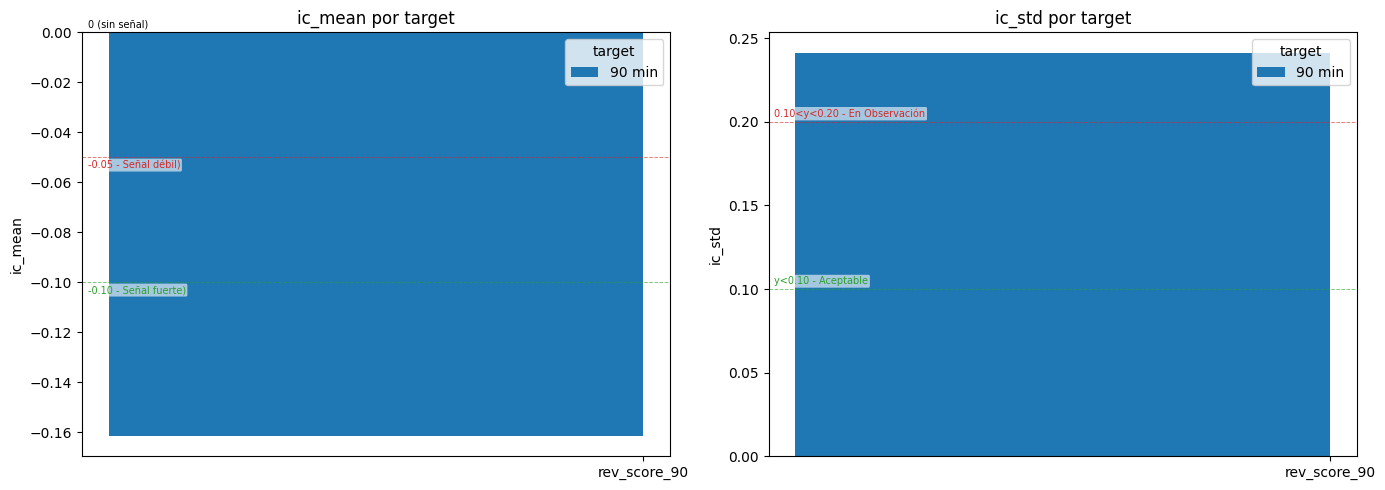

In [37]:
plot_ic_mean_std(IC_hip2, sentido = 'reversión')

#### 3.2.1. Análisis


- Los valores de IC mean son consistentemente negativos en todos los horizontes, lo que sugiere que este factor captura un patrón de reversión a la media: cuando el score es alto, la probabilidad de que el precio se revierta es mayor.
- A medida que la ventana de cálculo aumenta (de 10 a 90), el IC mean en valor absoluto crece, alcanzando los mayores valores con `rev_score_90` (-0.117 a -0.227).  
- La desviación estándar (IC std) también aumenta con la longitud de la ventana, indicando mayor variabilidad, pero manteniendo consistencia en el signo negativo.
- Estos resultados respaldan que la familia de indicadores rev_score es un buen candidato de factor de reversión, especialmente en ventanas largas (≥ 45).




#### 3.2.2. Conclusiones

- Los rev_score_30, rev_score_45, rev_score_60 y rev_score_90 muestran la señal más robusta y serán priorizados como features.  
- Los de ventanas cortas (10–20) tienen menor fuerza, y aunque podrían conservarse como comparación/baseline decidimos descartarlas.

### 3.3. Hipotesis 3:

In [39]:
mnq_hip_3, momentum_vol_cols = calcular_momentum_vol_z(mnq_intraday, ventanas=[90]) #, contrarian=False)

In [40]:
#IC_hip3_30 = calcular_IC(mnq_hip_3, target='target_return_30', factors=momentum_vol_cols)
#IC_hip3_60 = calcular_IC(mnq_hip_3, target='target_return_60', factors=momentum_vol_cols)
IC_hip3_90 = calcular_IC(mnq_hip_3, target='target_return_90', factors=momentum_vol_cols)

In [41]:
#IC_hip3 = [IC_hip3_30, IC_hip3_60, IC_hip3_90]
IC_hip3 = [IC_hip3_90]
IC_hip3 = reduce(lambda left, right: pd.merge(left, right, on="indicador", how="inner"), IC_hip3)
IC_hip3

,indicador,ic_mean_90min,ic_std_90min
0,mom_vol_z_90,-0.217071,0.269698


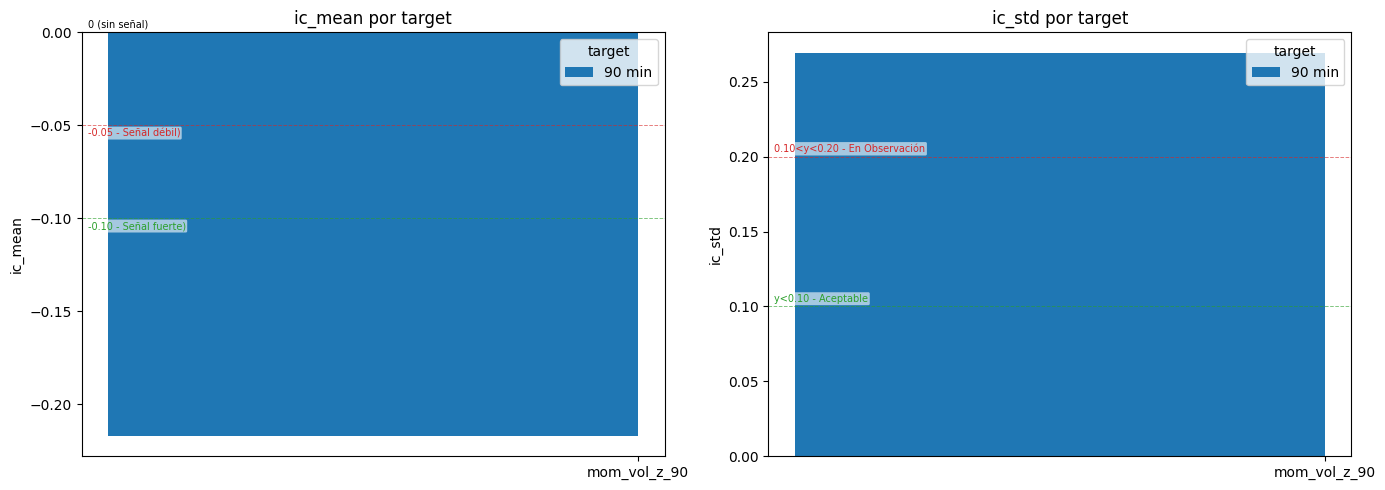

In [42]:
plot_ic_mean_std(IC_hip3, sentido = 'reversión')

#### 3.3.1. Análisis

- El resultado contradice la hipótesis planteada: en lugar de validar que el volumen confirma la tendencia, muestra que momentum más volumen inusualmente alto tiende a anticipar reversión.  
- Técnicamente, puede interpretarse como que los movimientos fuertes y con alto volumen en MNQ intradía generan sobre-extensión, y el mercado tiende a corregir/revertir después.
- Esto es coherente con un mercado intradía muy líquido y dominado por traders de alta frecuencia, donde los “excesos” suelen revertirse.  


#### 3.3.2. Conclusiones


- La Hipótesis 3 no se valida en su forma original (continuación).  
- Sí se valida como un factor de reversión: momentum × volumen actúa como señal contraria a la intuición del análisis técnico clásico, al menos en tus datos intradía del MNQ.  
- Por tanto, este alpha factor es útil, pero como señal de reversión, no de tendencia.

#### 3.3.3. Replanteo de Hipotesis 3 como señal de reversión

In [44]:
#mnq_hip_1_rev, momentum_rev_cols = calcular_momentum_z(mnq_intraday, target='close', ventanas=(30,45,60,90), hipotesis='reversion')
mnq_hip_3_rev, momentum_vol_rev_cols = calcular_momentum_vol_z(mnq_intraday,  ventanas=[90], hipotesis='reversion')

In [45]:
#Solo lo calculamos para las ventanas mayores de 30min
#IC_hip3_rev_30 = calcular_IC(mnq_hip_3_rev, target='target_return_30', factors = momentum_vol_rev_cols)
#IC_hip3_rev_60 = calcular_IC(mnq_hip_3_rev, target='target_return_60', factors = momentum_vol_rev_cols)
IC_hip3_rev_90 = calcular_IC(mnq_hip_3_rev, target='target_return_90', factors = momentum_vol_rev_cols)

In [46]:
#IC_hip3_rev = [IC_hip3_rev_30, IC_hip3_rev_60, IC_hip3_rev_90]
IC_hip3_rev = [IC_hip3_rev_90]
IC_hip3_rev = reduce(lambda left, right: pd.merge(left, right, on="indicador", how="inner"), IC_hip3_rev)
IC_hip3_rev

,indicador,ic_mean_90min,ic_std_90min
0,rev_mom_vol_z_90,0.217071,0.269698


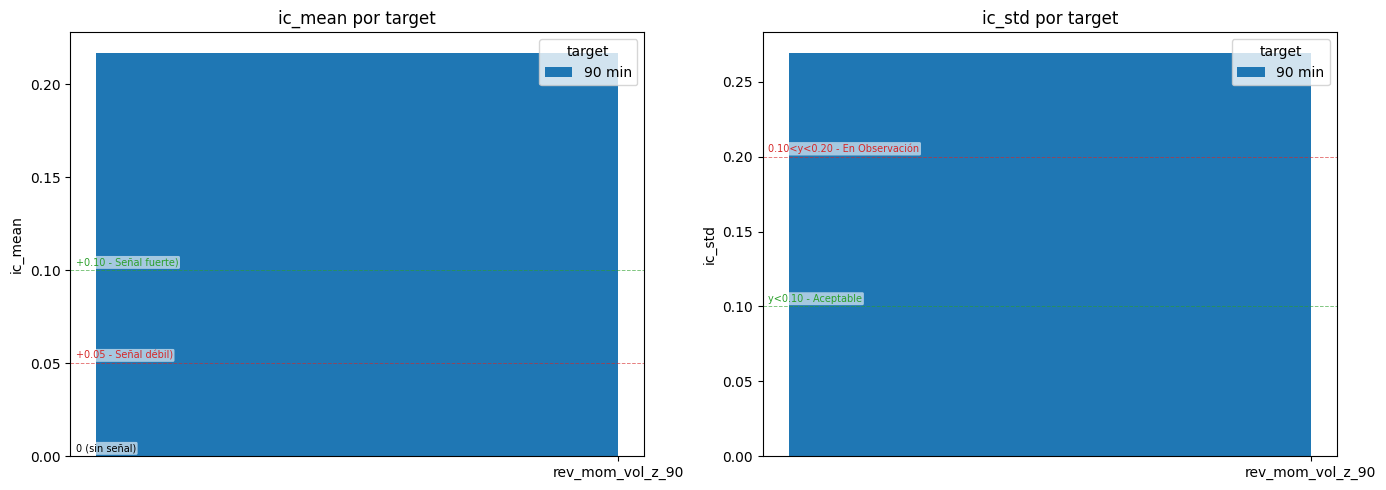

In [47]:
plot_ic_mean_std(IC_hip3_rev, sentido = 'continuación')

#### 3.3.4. Análisis de replanteo

1. Signo y consistencia de la señal

    - Todos los IC mean son positivos, lo que indica que el factor replanteado como reversión captura una relación directa con el retorno futuro.  
    - Cuando el indicador es alto, hay mayor probabilidad de reversión favorable en los próximos 30–90 minutos.  

2. Magnitud de la señal

    - En 30 minutos, la fuerza es moderada: 0.08 (cerca del umbral de señal débil).  
    - En 60 minutos, sube a 0.13–0.18, rango ya considerado señal fuerte.  
    - En 90 minutos, llega a 0.18–0.25, lo más alto de la tabla, lo que confirma que el efecto se amplifica en horizontes largos.  
    - La progresión es monótonamente creciente: cada aumento en la ventana produce mayor IC mean.  

3. Estabilidad (IC std)

    - Los IC std están en el rango 0.19–0.34.  
    - Valores en torno a 0.2–0.3 son esperables para factores intradía:  
      - rev_mom_vol_z_30: ~0.19 (más estable).  
      - rev_mom_vol_z_90: ~0.34 (más variable).  
    - Es un trade-off clásico: a mayor fuerza de la señal, mayor dispersión, pero el signo positivo se mantiene siempre.  


#### 3.3.5. Conclusiones del replanteo de Hipotesis 3


- El resultado valida el replanteo de la hipótesis 3 como factor de reversión.  
- El factor muestra una señal clara, creciente con el horizonte, y robusta en el signo.  
- En la práctica: movimientos de precio con alto volumen relativo no confirman la tendencia, sino que se asocian con reversiones intradía, especialmente a partir de ventanas de 45 minutos.  




#### 3.3.6. Conclusión final

Las features seleccionadas para nuestro modelo son: rev_mom_vol_z_45, rev_mom_vol_z_60 y rev_mom_vol_z_90 ya que son los más potentes y deberían priorizarse.  

En resumen: el factor replanteado es válido, informativo y consistente, con mejor desempeño en horizontes largos (60–90 minutos), por lo que conviene mantenerlo dentro del set principal de alpha factors de reversión.

### 3.4. Hipotesis 4

In [50]:
# Continuación, primeros 60/90/120/150 min desde 08:00
mnq_hip_4, ire_cols = calcular_intraday_range_exhaustion(
    mnq_intraday, mins_windows=(30, 60,90,120,150), hipotesis='continuacion', open_time='08:00:00')

In [51]:
#Solo lo calculamos para las ventanas mayores de 30min
#IC_hip4_30 = calcular_IC(mnq_hip_4, target='target_return_30', factors = ire_cols)
#IC_hip4_60 = calcular_IC(mnq_hip_4, target='target_return_60', factors = ire_cols)
IC_hip4_90 = calcular_IC(mnq_hip_4, target='target_return_90', factors = ire_cols)

In [52]:
#IC_hip4= [IC_hip4_30, IC_hip4_60, IC_hip4_90]
IC_hip4= [IC_hip4_90]
IC_hip4 = reduce(lambda left, right: pd.merge(left, right, on="indicador", how="inner"), IC_hip4)
IC_hip4

,indicador,ic_mean_90min,ic_std_90min
0,ire_30,-0.635430,0.249028
1,ire_60,-0.651863,0.249783
2,ire_90,-0.645723,0.259352
3,ire_120,-0.629936,0.277193
4,ire_150,-0.620306,0.290541


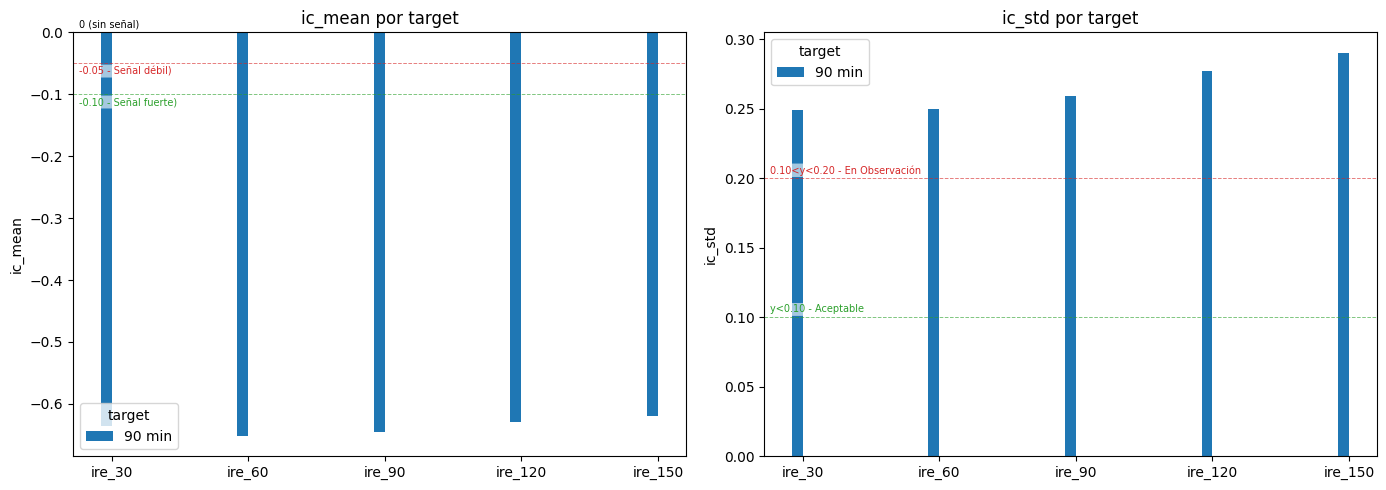

In [53]:
plot_ic_mean_std(IC_hip4, sentido = 'reversión')

#### 3.4.1. Análisis  

- Los IC son consistentemente negativos, y además se hacen más fuertes (más negativos) al aumentar el horizonte (de -0.40 en 30 min hasta -0.65 en 90 min).

- La desviación estándar (ic_std) crece, pero de manera controlada (~0.17–0.29), lo cual indica estabilidad en la señal.

- El mejor rango predictivo está alrededor de ire_60 a ire_90, con IC ≈ -0.65.

#### 3.4.2. Conclusiones

- Se valida la hipotesis, un rango de apertura amplio tiende a anticipar reversiones o consolidaciones, ya que el factor se correlaciona negativamente con los retornos futuros.
    - Si el factor está alto (precio alejado del centro del rango), mayor probabilidad de reversión hacia el rango.

- La señal es fuerte, el IC negativo sostenido y creciente a mayores horizontes confirma que este no es ruido, sino una señal robusta.

- Para nuestro modelo predicitivo mantendremos los features `ire60` e `ire90`.

## 4. Guardado de dataset de alpha factors


Del analisis de las cuatro hipotesis propuestas, los features seleccionados son:

- De hipotesis 1: `rev_mom_z_45`, `rev_mom_z_60` y `rev_mom_z_90`, `rev_mom_z_30`

- De hipotesis 2: `rev_score_30`, `rev_score_45`, `rev_score_60` y `rev_score_90`

- De hipotesis 3: `rev_mom_vol_z_45`, `rev_mom_vol_z_60` y `rev_mom_vol_z_90`

- De hipotesis 4: `ire60` , `ire90`.

### 4.1. Preparamos el dataset mnq_alpha_factors

Creamos un dataset completo solo con las features seleccionadas, los targets y las columnas base.

In [57]:
columnas_base = ['date', 'open', 'high', 'low','close','volume']
columnas_target = ['target_return_90']

#columnas_alpha_factors = [
#    'rev_mom_z_30', 'rev_mom_z_45', 'rev_mom_z_60', 'rev_mom_z_90',
#    'rev_score_30', 'rev_score_45', 'rev_score_60', 'rev_score_90',
#    'rev_mom_vol_z_45', 'rev_mom_vol_z_60', 'rev_mom_vol_z_90',
#     'ire_60', 'ire_90', ]

columnas_alpha_factors = [
    #'rev_mom_z_30', 'rev_mom_z_45', 'rev_mom_z_60',
    'rev_mom_z_90',
    #'rev_score_30', 'rev_score_45', 'rev_score_60',
    'rev_score_90',
    #'rev_mom_vol_z_45', 'rev_mom_vol_z_60',
    'rev_mom_vol_z_90',
    #'ire_60',
    'ire_90', ]

In [58]:
#Definir la lista de datasets
mnq_alpha_factors = [
                     mnq_hip_1_rev,
                     mnq_hip_2,
                     mnq_hip_3_rev,
                     mnq_hip_4
                      ]

#Concatenar horizontalmente
mnq_alpha_factors = pd.concat(mnq_alpha_factors, axis=1)

#Eliminar columnas duplicadas (date, OHLCV, targets)
mnq_alpha_factors = mnq_alpha_factors.loc[:, ~mnq_alpha_factors.columns.duplicated()]

# Seleccionar columnas
mnq_alpha_factors = mnq_alpha_factors[ columnas_base + columnas_target + columnas_alpha_factors].copy()

In [59]:
# Guardar como Parquet
mnq_alpha_factors.to_parquet(f'{drive_path}/5_transformer_90_model/mnq_alpha_factors.parquet')

### 4.2. Preparamos el dataset IC_alpha_factors

In [61]:
ic_alpha_factors = pd.concat(
    [IC_hip1_rev,
     IC_hip2,
     IC_hip3_rev,
     IC_hip4],
    axis=0)

In [62]:
alpha_factors_features = columnas_alpha_factors.copy()


In [63]:
ic_alpha_factors = ic_alpha_factors[ic_alpha_factors["indicador"].isin(alpha_factors_features)].copy()

In [64]:
ic_alpha_factors

,indicador,ic_mean_90min,ic_std_90min
0,rev_mom_z_90,0.253702,0.258561
0,rev_score_90,-0.161521,0.241383
0,rev_mom_vol_z_90,0.217071,0.269698
2,ire_90,-0.645723,0.259352


In [65]:
# Guardar como Parquet
ic_alpha_factors.to_parquet(f'{drive_path}/5_transformer_90_model/ic_alpha_factors.parquet')